## Series de tiempo - Taller 1

### Librerías usadas en el taller 1

In [2]:
import numpy as np                                    ### Cálculos numéricos y métricas descriptivas
import pandas as pd                                   ### Manejo, manipulación y transformación de datos
import matplotlib.pyplot as plt                       ### Gráficos básicos en Python  
import seaborn as sns                                 ### Gráficos estadísticos en Python

from pathlib import Path                              ### Manejo de rutas y directorios

#### Definimos la carpeta de destino

In [3]:
data_folder = Path.cwd().parent / 'data'

data_folder

WindowsPath('c:/Users/fevid/Documents/GitHub/time-series-Uniandes/data')

#### Cargamos la base de datos de nlsy79

In [4]:
df_1 = pd.read_excel(data_folder/'nlsy79_regresion.xlsx')

df_1.head(10)

,salario_hora,no_ambos_padres_bio,educacion,edad,afqt_score,mujer,hispano,negro
0,6.78,0,12,51,12.0,1,0,0
1,43.41,0,16,49,99.0,0,0,0
2,14.35,1,12,45,33.0,0,0,0
3,20.19,0,14,51,43.0,1,0,0
4,21.15,1,14,46,55.0,0,0,0
5,40.59,0,19,46,88.0,1,0,0
6,NaN,0,16,45,83.0,0,0,0
7,28.63,0,13,51,63.0,1,0,0
8,27.02,1,13,53,84.0,0,0,0
9,NaN,0,12,51,NaN,1,0,0


#### Propuesta de modelo de predicción:

$Ln(W_{i}) = \beta_{0} + \beta_{1}S_{i} + \beta_{2}AFQT_{i} + \beta_{3}Mujer_{i} + \beta_{4}Hispano_{i} + \beta_{5}Negro + \epsilon_{i}$

$W_{i}:$ es el nivel salarial por hora de la persona $i$ en dólares americanos

$S_{i}:$ el número de años de escolaridad reportado por la persona $i$

$AFQT_{i}:$ puntaje percentil en el Armed Forces Qualification Test de la persona $i$ (proxy de habilidad cognitiva).

$Mujer_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ es mujer y 0 si es hombre.

$Hispano_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ pertenece a este grupo étnico/racial y 0 en caso contrario.

$Negro_{i}:$ variable dummy que toma el valor de 1 si la persona $i$ pertenece a este grupo étnico/racial y 0 en caso contrario.

$\epsilon_{i}:$ error de medición


## Preliminares:

<b>1) ¿Cuál es el pronóstico óptimo para el salario de la persona i?<b>

<b>b) Discuta los supuestos necesarios para que el pronóstico propuesto sea, de hecho, óptimo<b>



<b>2) Usando las observaciones de la muestra (las que reportan salarios), haga diagramas de dispersión del logaritmo natural de los salarios con respecto a la educación y al puntaje AFQT. Discuta qué espera de los parámetros del modelo en términos de signo y significancia<b>

In [ ]:
#### Filtramos los NaN para las variables de salarios por hora, AFQT y Educación
df_wage = df_1.dropna(subset = ['salario_hora', 
                                'afqt_score', 
                                'educacion'])

#### Creamos la variable del logaritmo natural de los salarios
df_wage['ln_salario_hora'] = np.log(df_wage['salario_hora'])

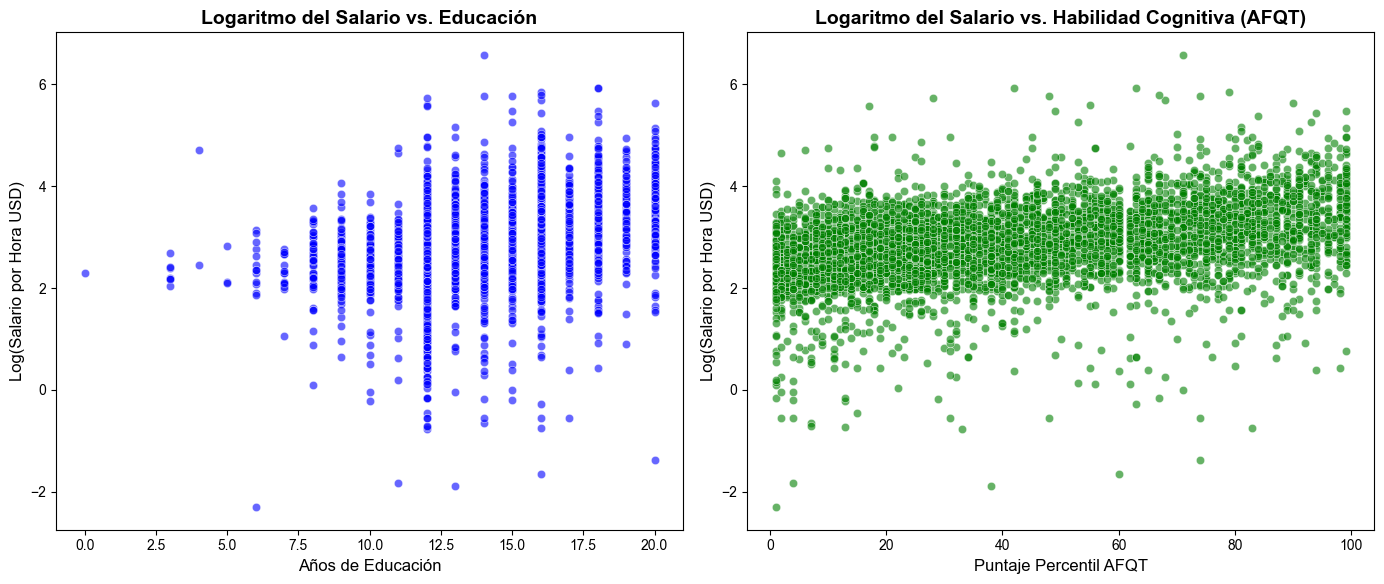

In [ ]:
fig, axes = plt.subplots(nrows = 1, 
                         ncols = 2, 
                         figsize = (14, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data = df_wage, 
    x = 'educacion', 
    y = 'ln_salario_hora', 
    alpha =0.6, 
    ax = axes[0],
    color = 'blue'
)
axes[0].set_title('Logaritmo del Salario vs. Educación', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Años de Educación', fontsize=12)
axes[0].set_ylabel('Log(Salario por Hora USD)', fontsize=12)

sns.scatterplot(
    data = df_wage, 
    x = 'afqt_score', 
    y = 'ln_salario_hora', 
    alpha = 0.6, 
    ax = axes[1],
    color = 'green'
)
axes[1].set_title('Logaritmo del Salario vs. Habilidad Cognitiva (AFQT)', 
                  fontsize = 14, 
                  fontweight = 'bold')
axes[1].set_xlabel('Puntaje Percentil AFQT', 
                   fontsize = 12)
axes[1].set_ylabel('Log(Salario por Hora USD)', 
                   fontsize = 12)

plt.tight_layout()
plt.show()

La gráfica de la Educación vs el logaritmo del salario muestra una relación lineal positiva, sin embargo, existe una elevada dispersión de los datos para cada año de educación, por lo tanto esperamos que el signo del estimador de los años de educación sea positivo y significativo bajo una confianza del 95%. Por otra parte, la gráfica del AFQT también mustra una relación positiva con una menor dispersión, aunque con más cantidad de datos atípicos